In [14]:
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report

In [15]:
file_path = r'C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\fingerprint-based-blood-group-detection-main\dataset\dataset_blood_group'

# List all classes in the dataset
name_class = os.listdir(file_path)
print(name_class)

['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


In [16]:
# Get file paths for all images in the dataset
filepaths = list(glob.glob(file_path + '/**/*.*'))

# Example of printing a subset of file paths
print(filepaths[-6:-1])

# Extract labels from file paths
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
print(labels)

['C:\\Users\\cheth\\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\\fingerprint-based-blood-group-detection-main\\dataset\\dataset_blood_group\\O-\\cluster_7_964.BMP', 'C:\\Users\\cheth\\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\\fingerprint-based-blood-group-detection-main\\dataset\\dataset_blood_group\\O-\\cluster_7_977.BMP', 'C:\\Users\\cheth\\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\\fingerprint-based-blood-group-detection-main\\dataset\\dataset_blood_group\\O-\\cluster_7_979.BMP', 'C:\\Users\\cheth\\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\\fingerprint-based-blood-group-detection-main\\dataset\\dataset_blood_group\\O-\\cluster_7_985.BMP', 'C:\\Users\\cheth\\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\\fingerprint-based-blood-group-detection-main\\dataset\\dataset_blood_group\\O-\\cluster_7_998.BMP']
['A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', '

                                            Filepath Label
0  C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FIN...   AB-
1  C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FIN...   AB-
2  C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FIN...    O-
3  C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FIN...    A-
4  C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FIN...    O-


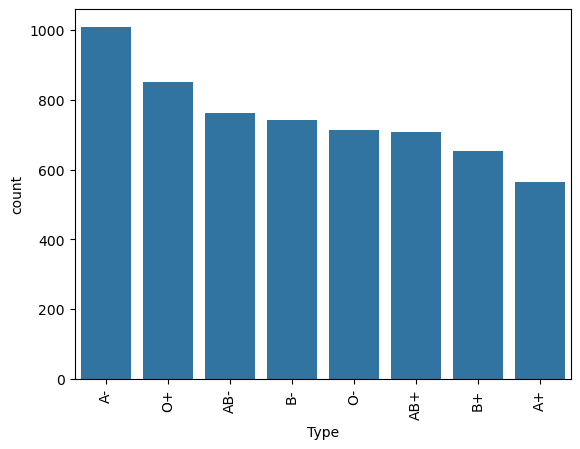

In [17]:
# Create a DataFrame with file paths and labels
filepath = pd.Series(filepaths, name='Filepath').astype(str)
Labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, Labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
print(data.head(5))

# Visualize class distribution
counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90)
plt.show()

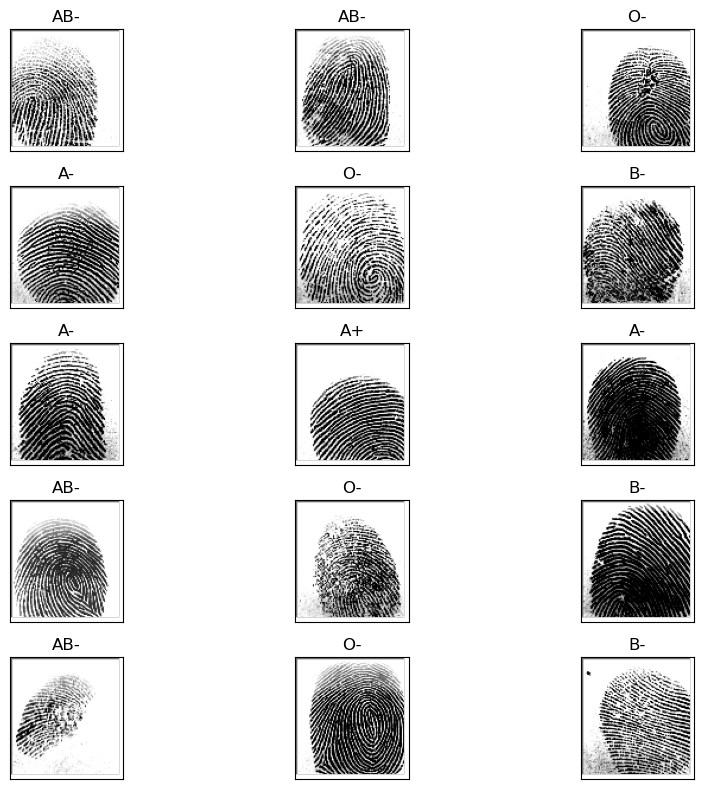

In [18]:
# Split data into training and testing sets
train, test = train_test_split(data, test_size=0.20, random_state=42)

# Visualize some images from the dataset
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 8), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(data.Filepath[i]))
    ax.set_title(data.Label[i])
plt.tight_layout()
plt.show()

In [19]:
# Set up ImageDataGenerator for training and validation data
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

valid_gen = train_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)

Found 4800 validated image filenames belonging to 8 classes.
Found 1200 validated image filenames belonging to 8 classes.


In [20]:
from tensorflow.keras.applications import VGG16

# Define the base pre-trained model
vgg16_base = VGG16(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

vgg16_base.trainable = False

# Add layers for classification on top of VGG16
x = Dense(128, activation="relu")(vgg16_base.output)
x = Dense(128, activation="relu")(x)
outputs = Dense(8, activation='softmax')(x)

vgg16_model = Model(inputs=vgg16_base.input, outputs=outputs)

vgg16_model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


from tensorflow.keras.callbacks import ModelCheckpoint

# Define checkpoint callback
checkpoint = ModelCheckpoint("vgg16_checkpoint.h5", save_best_only=False, save_weights_only=False)

# Train the model with checkpointing
history = vgg16_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,   # Total epochs
    callbacks=[checkpoint]  # Add this callback
)



# Train the model
#history = vgg16_model.fit(
 #   train_gen,
  #  validation_data=valid_gen,
   # epochs=20,
    
#)

Epoch 1/20
150/150 [==============================] - 2005s 13s/step - loss: 1.2893 - accuracy: 0.5250 - val_loss: 1.0104 - val_accuracy: 0.6242
Epoch 2/20
150/150 [==============================] - 1982s 13s/step - loss: 0.8149 - accuracy: 0.6769 - val_loss: 0.8676 - val_accuracy: 0.6742
Epoch 3/20
150/150 [==============================] - 2081s 14s/step - loss: 0.6402 - accuracy: 0.7498 - val_loss: 0.8587 - val_accuracy: 0.6625
Epoch 4/20
150/150 [==============================] - 2008s 13s/step - loss: 0.5495 - accuracy: 0.7877 - val_loss: 0.7825 - val_accuracy: 0.7125
Epoch 5/20
150/150 [==============================] - 2011s 13s/step - loss: 0.4739 - accuracy: 0.8165 - val_loss: 0.7739 - val_accuracy: 0.7117
Epoch 6/20
150/150 [==============================] - 1494s 10s/step - loss: 0.4517 - accuracy: 0.8188 - val_loss: 0.7681 - val_accuracy: 0.7225
Epoch 7/20
150/150 [==============================] - 1996s 13s/step - loss: 0.3913 - accuracy: 0.8487 - val_loss: 0.8536 - val_ac

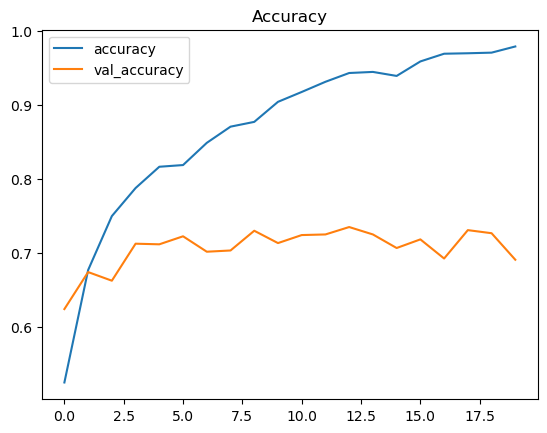

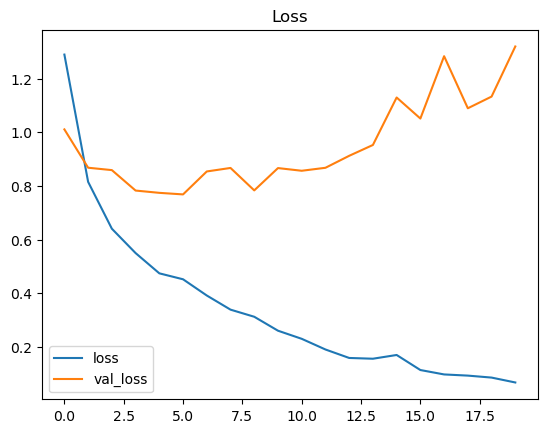

Test Loss: 1.31948
Test Accuracy: 69.08%
38/38 [==============================] - 394s 10s/step
              precision    recall  f1-score   support

          A+       0.76      0.79      0.77       121
          A-       0.53      0.81      0.64       183
         AB+       0.79      0.53      0.63       161
         AB-       0.72      0.70      0.71       146
          B+       0.75      0.66      0.70       135
          B-       0.89      0.74      0.81       135
          O+       0.65      0.67      0.66       182
          O-       0.68      0.64      0.66       137

    accuracy                           0.69      1200
   macro avg       0.72      0.69      0.70      1200
weighted avg       0.71      0.69      0.69      1200



In [21]:
# Plot training history: accuracy
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title("Accuracy")
plt.show()
  
# Plot training history: loss
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title("Loss")
plt.show()

# Evaluate the model on test data
results = vgg16_model.evaluate(valid_gen, verbose=0)
print(f"Test Loss: {results[0]:.5f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

# Predict labels for test data
pred = vgg16_model.predict(valid_gen)
pred = np.argmax(pred, axis=1)

# Map predicted labels
labels = train_gen.class_indices
labels = dict((v, k) for k, v in labels.items())
pred = [labels[k] for k in pred]

# Compare predicted labels with true labels and print classification report
y_test = list(test.Label)
print(classification_report(y_test, pred))

In [24]:
vgg16_model.save("model_blood_group_detection_vgg16.h5")

1/1 [==============================] - 1s 821ms/step


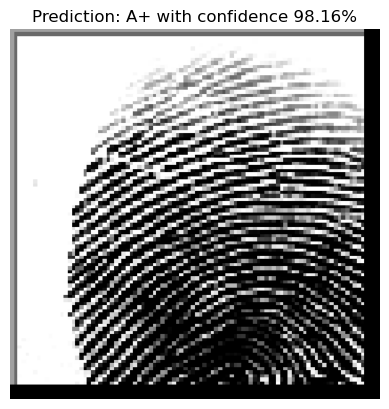

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Load the pre-trained model
model = load_model('model_blood_group_detection_vgg16.h5')

# Define the class labels
labels = {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
labels = dict((v, k) for k, v in labels.items())

# Example of loading a single image and making a prediction
img_path = r'C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\fingerprint-based-blood-group-detection-main\dataset\dataset_blood_group\A+\cluster_0_1001.BMP'

img = image.load_img(img_path, target_size=(256, 256))  # Load the image
x = image.img_to_array(img)  # Convert image to array
x = np.expand_dims(x, axis=0)  # Expand dimensions to match the model input
x = preprocess_input(x)  # Preprocess the image

result = model.predict(x)  # Predict using the model
predicted_class = np.argmax(result)  # Get the predicted class index

# Map the predicted class to the label
predicted_label = labels[predicted_class]
confidence = result[0][predicted_class] * 100  # Confidence level

# Display the image
plt.imshow(image.array_to_img(image.img_to_array(img) / 255.0))
plt.axis('off')  # Hide axes

# Display the prediction and confidence below the image
plt.title(f"Prediction: {predicted_label} with confidence {confidence:.2f}%")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Load the pre-trained model
model = load_model('model_blood_group_detection_vgg16.h5')

# Define the class labels
labels = {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
labels = dict((v, k) for k, v in labels.items())

# Example of loading a single image and making a prediction
img_path = r'C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\fingerprint-based-blood-group-detection-main\dataset\dataset_blood_group\AB+\cluster_4_51.BMP'

img = image.load_img(img_path, target_size=(256, 256))  # Load the image
x = image.img_to_array(img)  # Convert image to array
x = np.expand_dims(x, axis=0)  # Expand dimensions to match the model input
x = preprocess_input(x)  # Preprocess the image

result = model.predict(x)  # Predict using the model
predicted_class = np.argmax(result)  # Get the predicted class index

# Map the predicted class to the label
predicted_label = labels[predicted_class]
confidence = result[0][predicted_class] * 100  # Confidence level

# Display the image
plt.imshow(image.array_to_img(image.img_to_array(img) / 255.0))
plt.axis('off')  # Hide axes

# Display the prediction and confidence below the image
plt.title(f"Prediction: {predicted_label} with confidence {confidence:.2f}%")
plt.show()


1/1 [==============================] - 1s 855ms/step


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Load the pre-trained model
model = load_model('model_blood_group_detection_vgg16.h5')

# Define the class labels
labels = {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
labels = dict((v, k) for k, v in labels.items())

# Example of loading a single image and making a prediction
img_path = r'C:\Users\cheth\BLOOD_GROUP_DETECTION_USING_FINGERPRINTS\fingerprint-based-blood-group-detection-main\dataset\dataset_blood_group\O-\cluster_7_430.BMP'

img = image.load_img(img_path, target_size=(256, 256))  # Load the image
x = image.img_to_array(img)  # Convert image to array
x = np.expand_dims(x, axis=0)  # Expand dimensions to match the model input
x = preprocess_input(x)  # Preprocess the image

result = model.predict(x)  # Predict using the model
predicted_class = np.argmax(result)  # Get the predicted class index

# Map the predicted class to the label
predicted_label = labels[predicted_class]
confidence = result[0][predicted_class] * 100  # Confidence level

# Display the image
plt.imshow(image.array_to_img(image.img_to_array(img) / 255.0))
plt.axis('off')  # Hide axes

# Display the prediction and confidence below the image
plt.title(f"Prediction: {predicted_label} with confidence {confidence:.2f}%")
plt.show()


1/1 [==============================] - 1s 922ms/step
